# PCOS Detection using Machine Learning
**Course:** 24CAI0203 — Supervised & Unsupervised Machine Learning  
**Dataset:** PCOS Extended Dataset (2000 patients, 44 features)  
**Goal:** Predict whether a patient has PCOS (Polycystic Ovary Syndrome) based on medical parameters.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('PCOS_extended_dataset.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (2000, 44)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


## 3. Data Exploration

In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3    Age (yrs)              2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   

In [4]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('Target class distribution:')
print(df['PCOS (Y/N)'].value_counts())
print(f"PCOS cases: {df['PCOS (Y/N)'].sum()} | Non-PCOS: {(df['PCOS (Y/N)'] == 0).sum()}")

Missing values per column:
Marraige Status (Yrs)    3
dtype: int64

Target class distribution:
PCOS (Y/N)
0    1392
1     608
Name: count, dtype: int64
PCOS cases: 608 | Non-PCOS: 1392


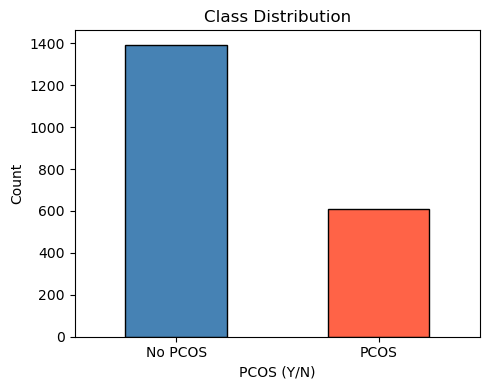

In [5]:
# Visualise target distribution
plt.figure(figsize=(5, 4))
df['PCOS (Y/N)'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No PCOS', 'PCOS'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [6]:
# Drop ID/administrative columns that are not medical features
df_clean = df.drop(columns=['Sl. No', 'Patient File No.'])

# Fix dirty values in two columns:
# 'II beta-HCG' has '1.99.' (extra dot) and 'AMH' has 'a' — convert to NaN, then fill with median
df_clean['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df_clean['II    beta-HCG(mIU/mL)'], errors='coerce')
df_clean['AMH(ng/mL)']             = pd.to_numeric(df_clean['AMH(ng/mL)'],             errors='coerce')

# Fill ALL remaining missing values (including the 3 in Marraige Status) with column median
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Confirm no missing values remain
print('Missing values after cleaning:', df_clean.isnull().sum().sum())
print('Dataset ready. Shape:', df_clean.shape)

Missing values after cleaning: 0
Dataset ready. Shape: (2000, 42)


## 5. Feature Selection & Train-Test Split

In [7]:
# Define features (X) and target (y)
X = df_clean.drop(columns=['PCOS (Y/N)'])
y = df_clean['PCOS (Y/N)']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Features shape: (2000, 41)
Target shape: (2000,)
Training samples: 1600
Testing samples:  400


In [8]:
# Scale features (important for Logistic Regression, SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling complete.')

Feature scaling complete.


## 6. Model Training

In [9]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print(f'Logistic Regression Accuracy: {lr_acc:.4f}')

Logistic Regression Accuracy: 0.9450


In [10]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)   # tree-based: no scaling needed
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f'Decision Tree Accuracy: {dt_acc:.4f}')

Decision Tree Accuracy: 0.9900


In [11]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_acc:.4f}')

Random Forest Accuracy: 0.9950


In [12]:
# --- SVM ---
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Accuracy: {svm_acc:.4f}')

SVM Accuracy: 0.9675


In [13]:
# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
print(f'KNN Accuracy: {knn_acc:.4f}')

KNN Accuracy: 0.9375


## 7. Model Comparison

In [14]:
# Summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN'],
    'Accuracy': [lr_acc, dt_acc, rf_acc, svm_acc, knn_acc]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results.to_string(index=False))

              Model  Accuracy  Accuracy (%)
      Random Forest    0.9950         99.50
      Decision Tree    0.9900         99.00
                SVM    0.9675         96.75
Logistic Regression    0.9450         94.50
                KNN    0.9375         93.75


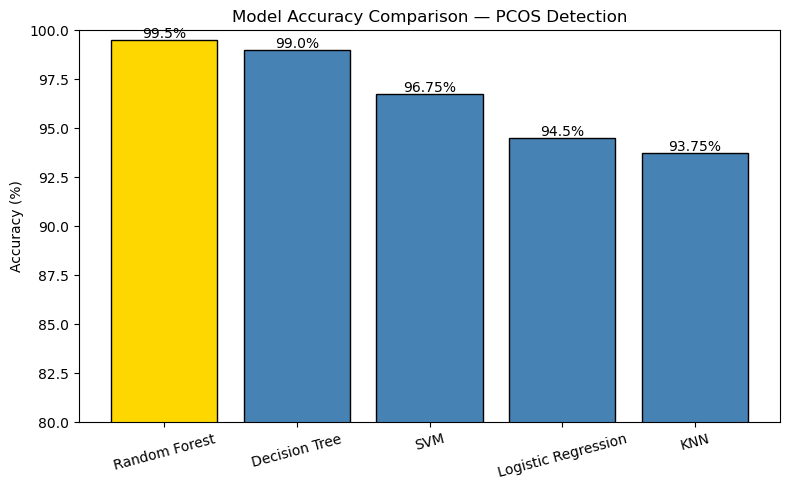

In [15]:
# Bar chart comparison
plt.figure(figsize=(8, 5))
colors = ['gold' if m == 'Random Forest' else 'steelblue' for m in results['Model']]
bars = plt.bar(results['Model'], results['Accuracy (%)'], color=colors, edgecolor='black')
plt.ylim(80, 100)
plt.title('Model Accuracy Comparison — PCOS Detection')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=15)
for bar, val in zip(bars, results['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Detailed Evaluation — Best Model (Random Forest)

In [16]:
print('Classification Report — Random Forest:')
print(classification_report(y_test, rf_pred, target_names=['No PCOS', 'PCOS']))

Classification Report — Random Forest:
              precision    recall  f1-score   support

     No PCOS       1.00      1.00      1.00       278
        PCOS       0.99      0.99      0.99       122

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



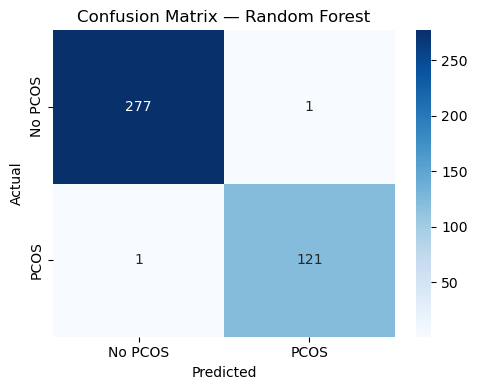

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No PCOS', 'PCOS'],
            yticklabels=['No PCOS', 'PCOS'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Top 15 Features)

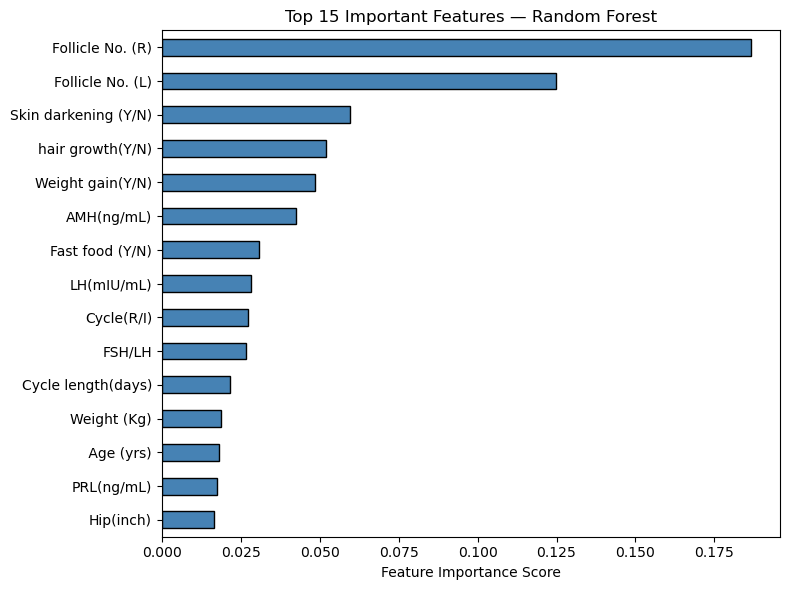

Top 5 predictors:
Follicle No. (R)        0.186442
Follicle No. (L)        0.124783
Skin darkening (Y/N)    0.059628
hair growth(Y/N)        0.051846
Weight gain(Y/N)        0.048643
dtype: float64


In [18]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 15 Important Features — Random Forest')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 predictors:')
print(feat_imp.head())

## 10. Prediction on New Patient Data

In [19]:
# Use one sample from test set as demo
sample = X_test.iloc[[0]]
prediction = rf.predict(sample)[0]
actual = y_test.iloc[0]

print('--- PCOS Detection System ---')
print(f'Prediction : {"PCOS Detected" if prediction == 1 else "No PCOS"}')
print(f'Actual     : {"PCOS" if actual == 1 else "No PCOS"}')

--- PCOS Detection System ---
Prediction : No PCOS
Actual     : No PCOS


## 11. Limitations

- The dataset is synthetic/extended and may not fully represent clinical populations.
- Blood Group is encoded as integer, which may mislead distance-based models (KNN, SVM).
- No hyperparameter tuning was performed — accuracy can be further improved.
- The model should not be used as a standalone clinical diagnostic tool.